# GraphServe: repository understanding and multi-node inference

This notebook analyzes committed measurements from two real Ray Serve/vLLM
profiles on a three-node K3s cluster. It reads raw repository artifacts rather
than relying on hand-entered results. Benchmark timestamps are 2026-10-01 UTC.

## System under test

- One control node runs nginx, the Python agent, SIE, the inference gateway, Ray head, Prometheus and Grafana.
- Two A100-SXM4-40GB workers run one full Qwen2.5-Coder-7B-Instruct BF16 replica each.
- Configuration A disables automatic prefix caching and uses default routing.
- Configuration B enables automatic prefix caching and Ray prefix-affinity routing.
- Each measured phase contains 12 requests after two warmups.

In [1]:
from pathlib import Path
import json, math, html
from IPython.display import Markdown, SVG, display

ROOT = Path.cwd()
if not (ROOT / "benchmarks").exists() and (ROOT.parent / "benchmarks").exists():
    ROOT = ROOT.parent
if not (ROOT / "benchmarks").exists():
    raise FileNotFoundError("Run this notebook from the GraphServe repository root")

CONFIGS = {
    "A — default": ROOT / "benchmarks/config-a-multinode-default",
    "B — prefix affinity": ROOT / "benchmarks/config-b-multinode-prefix-aware",
}
summaries = {name: json.loads((path / "summary.json").read_text()) for name, path in CONFIGS.items()}
requests = {name: [json.loads(line) for line in (path / "requests.jsonl").read_text().splitlines()]
            for name, path in CONFIGS.items()}
print("Loaded:", ", ".join(f"{name} ({len(requests[name])} records)" for name in CONFIGS))

Loaded: A — default (38 records), B — prefix affinity (38 records)


## End-to-end application results

Latency is for successful `/questions` requests. Throughput also counts successful requests, so the B concurrency-4 failure rate must be read alongside it.

In [2]:
rows = []
for name, summary in summaries.items():
    for phase in summary["phases"]:
        rows.append({"config": name, **phase})

lines = []
lines.append("| Configuration | C | Success | Requests/s | p50 (s) | p95 (s) | Tokens/s |")
lines.append("|---|---:|---:|---:|---:|---:|---:|")
for row in rows:
    lines.append(f"| {row['config']} | {row['concurrency']} | {row['successful']}/{row['requests']} | "
          f"{row['request_throughput_per_s']:.3f} | {row['latency_p50_s']:.2f} | "
          f"{row['latency_p95_s']:.2f} | {row['total_tokens_per_s']:.0f} |")
display(Markdown("\n".join(lines)))


| Configuration | C | Success | Requests/s | p50 (s) | p95 (s) | Tokens/s |
|---|---:|---:|---:|---:|---:|---:|
| A — default | 1 | 12/12 | 0.138 | 6.38 | 11.13 | 738 |
| A — default | 2 | 12/12 | 0.285 | 6.46 | 10.73 | 1524 |
| A — default | 4 | 12/12 | 0.492 | 6.62 | 12.06 | 2633 |
| B — prefix affinity | 1 | 12/12 | 0.143 | 6.15 | 10.75 | 765 |
| B — prefix affinity | 2 | 12/12 | 0.272 | 5.78 | 13.41 | 1459 |
| B — prefix affinity | 4 | 8/12 | 0.038 | 43.60 | 80.92 | 199 |

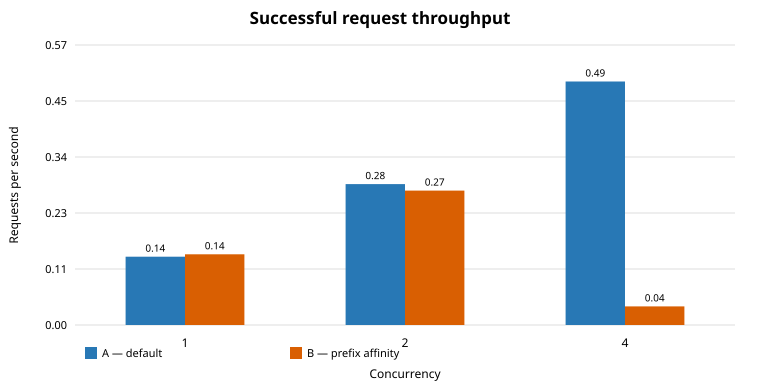

In [3]:
COLORS = {"A — default": "#2878B5", "B — prefix affinity": "#D95F02"}

def grouped_svg(metric, title, ylabel, width=760, height=390):
    concurrencies = [1, 2, 4]
    names = list(CONFIGS)
    vals = {(r["config"], r["concurrency"]): float(r[metric]) for r in rows}
    top = max(vals.values()) * 1.15 or 1
    left, right, upper, bottom = 75, 25, 45, 65
    plot_w, plot_h = width-left-right, height-upper-bottom
    p = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">',
         '<rect width="100%" height="100%" fill="white"/>',
         f'<text x="{width/2}" y="24" text-anchor="middle" font-family="sans-serif" font-size="17" font-weight="bold">{html.escape(title)}</text>']
    for i in range(6):
        v, y = top*i/5, upper+plot_h-plot_h*i/5
        p += [f'<line x1="{left}" x2="{left+plot_w}" y1="{y:.1f}" y2="{y:.1f}" stroke="#ddd"/>',
              f'<text x="{left-8}" y="{y+4:.1f}" text-anchor="end" font-family="sans-serif" font-size="11">{v:.2f}</text>']
    group_w, bar_w = plot_w/len(concurrencies), plot_w/len(concurrencies)*0.27
    for gi, c in enumerate(concurrencies):
        center = left+group_w*(gi+0.5)
        for ni, name in enumerate(names):
            value = vals[(name, c)]; bar_h = value/top*plot_h
            x = center+(ni-0.5)*bar_w-bar_w/2; y = upper+plot_h-bar_h
            p += [f'<rect x="{x:.1f}" y="{y:.1f}" width="{bar_w:.1f}" height="{bar_h:.1f}" fill="{COLORS[name]}"/>',
                  f'<text x="{x+bar_w/2:.1f}" y="{max(upper+10,y-5):.1f}" text-anchor="middle" font-family="sans-serif" font-size="10">{value:.2f}</text>']
        p.append(f'<text x="{center:.1f}" y="{upper+plot_h+22}" text-anchor="middle" font-family="sans-serif" font-size="12">{c}</text>')
    p += [f'<text x="{left+plot_w/2}" y="{height-12}" text-anchor="middle" font-family="sans-serif" font-size="12">Concurrency</text>',
          f'<text transform="translate(18 {upper+plot_h/2}) rotate(-90)" text-anchor="middle" font-family="sans-serif" font-size="12">{html.escape(ylabel)}</text>']
    for i, name in enumerate(names):
        p += [f'<rect x="{left+10+i*205}" y="{height-43}" width="12" height="12" fill="{COLORS[name]}"/>',
              f'<text x="{left+27+i*205}" y="{height-33}" font-family="sans-serif" font-size="11">{html.escape(name)}</text>']
    return ''.join(p+['</svg>'])

display(SVG(grouped_svg("request_throughput_per_s", "Successful request throughput", "Requests per second")))

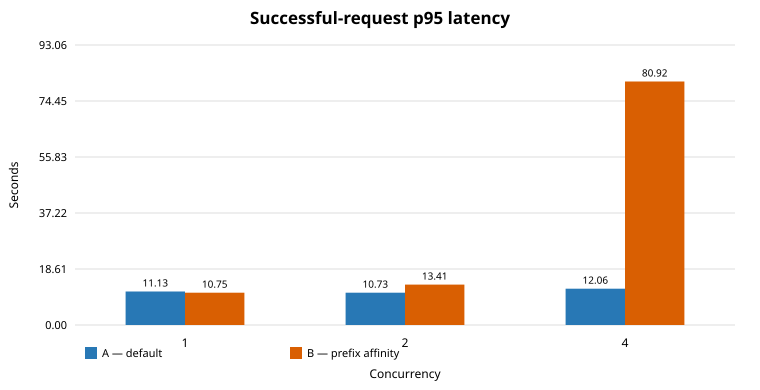

In [4]:
display(SVG(grouped_svg("latency_p95_s", "Successful-request p95 latency", "Seconds")))

## Serving telemetry

These are maxima observed in each saved Prometheus range. TTFT is an aggregate histogram estimate, not a per-request timestamp. A value of 100% GPU utilization is a sampled peak, not a phase average.

In [5]:
def metric_max(config_path, concurrency, key):
    payload = json.loads((config_path / f"metrics-c{concurrency}.json").read_text())
    values = []
    for series in payload.get(key, {}).get("result", []):
        for _, raw in series.get("values", []):
            try: value = float(raw)
            except (TypeError, ValueError): continue
            if math.isfinite(value): values.append(value)
    return max(values) if values else None

lines = []
lines.append("| Configuration | C | max aggregate TTFT p95 (s) | max KV use | max Serve queue | max GPU use |")
lines.append("|---|---:|---:|---:|---:|---:|")
for name, path in CONFIGS.items():
    for c in (1, 2, 4):
        ttft = metric_max(path, c, "ttft_p95")
        kv = metric_max(path, c, "kv_cache")
        queue = metric_max(path, c, "serve_queued")
        gpu = metric_max(path, c, "gpu_utilization")
        lines.append(f"| {name} | {c} | {ttft:.3f} | {kv*100:.2f}% | {queue:.0f} | {gpu:.0f}% |")
display(Markdown("\n".join(lines)))


| Configuration | C | max aggregate TTFT p95 (s) | max KV use | max Serve queue | max GPU use |
|---|---:|---:|---:|---:|---:|
| A — default | 1 | 0.959 | 1.13% | 0 | 100% |
| A — default | 2 | 0.488 | 0.89% | 0 | 100% |
| A — default | 4 | 0.488 | 1.11% | 0 | 100% |
| B — prefix affinity | 1 | 0.948 | 1.54% | 0 | 100% |
| B — prefix affinity | 2 | 0.485 | 1.54% | 0 | 100% |
| B — prefix affinity | 4 | 0.444 | 1.13% | 3 | 100% |

## Failure evidence

Failures remain in `requests.jsonl`; they are not included in successful-request latency percentiles.

In [6]:
failures = [(name, row) for name, records in requests.items() for row in records
            if row.get("phase") != "warmup" and not row.get("ok")]
print(f"Measured failures: {len(failures)}")
for name, row in failures:
    print(f"- {name}: seq={row['sequence']} phase={row['phase']} status={row['status_code']} "
          f"latency={row['latency_s']:.2f}s — {row['question']}")

Measured failures: 4
- seq=26 phase=c4 status=502 latency=124.70s question=Trace a text request from the gateway through routing, worker selection, and completion.
- seq=28 phase=c4 status=502 latency=125.66s question=Explain how prefill and decode KV transfer works with Mooncake.
- seq=29 phase=c4 status=502 latency=124.65s question=How does the planner decide whether to add prefill or decode replicas?
- seq=30 phase=c4 status=502 latency=122.76s question=Propose adding a circuit breaker to overflow calls. Name the files and tests to change.


## Interpretation

Configuration A completed all 36 measured requests and reached 0.492 successful requests/s at concurrency 4 with 12.06 s p95. Configuration B was close at concurrency 1, slower in tail latency at concurrency 2, and failed four concurrency-4 calls after upstream inference timeouts. Its eight successful concurrency-4 calls had 80.92 s p95.

B changes both vLLM automatic prefix caching and routing, so this run cannot assign causality to either change. A better follow-up enables prefix caching with default routing, then treats prefix-affinity routing as a third profile. The stable A profile was restored after measurement.

## Reproducibility checks

In [7]:
assert [p["successful"] for p in summaries["A — default"]["phases"]] == [12, 12, 12]
assert [p["successful"] for p in summaries["B — prefix affinity"]["phases"]] == [12, 12, 8]
assert len(failures) == 4 and all(row["status_code"] == 502 for _, row in failures)
assert "enable_prefix_caching: false" in (CONFIGS["A — default"] / "rayservice.yaml").read_text()
assert "enable_prefix_caching: true" in (CONFIGS["B — prefix affinity"] / "rayservice.yaml").read_text()
print("Evidence assertions passed: summaries, failures, and serving manifests agree.")

Evidence assertions passed: summaries, failures, and serving manifests agree.


## Limitations and remaining evidence

- `/questions` is non-streaming, so this notebook does not claim per-request TTFT or inter-token latency.
- One run per profile is insufficient for confidence intervals.
- The workload does not isolate identical, shared, partial, and unique prefixes.
- Source IDs and immutable blobs are verified, but answer correctness and semantic citation entailment are not scored.
- Explicit tenant admission, per-worker placement, bounded queues, overflow, and cold-recompute telemetry remain future work.

The current evidence supports configuration A as the safer profile for this workload. The final PDF should be exported only after streaming and quality measurements are appended.